# Hybrid Apriori Algorithm (Using Multiple Minimum Item Supports - MIS)

**Module :** Fouille de données  
**Niveau :** M1 – Informatique Visuelle  
**Binôme :** Sellami Mohamed Amine et Abdesselam Meriem — G3

**Approche :** Nous utilisons l'extension **Multiple Minimum Item Supports (MIS)** basée sur l'article de Liu et al. (1999).  

In [ ]:
import pandas as pd
from itertools import combinations
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

### Loading the Data

In [ ]:
def charger_donnees(fichier):
    df = pd.read_csv(fichier, header=None, dtype=str)
    transactions = [
        sorted([str(item).strip() for item in row if str(item).strip() != 'nan'])
        for _, row in df.iterrows()
    ]
    return [t for t in transactions if t]

### Support Calculation

In [ ]:
def calculer_support(itemset, transactions):
    n = len(transactions)
    if n == 0:
        return 0.0
    return sum(1 for t in transactions if itemset.issubset(t)) / n

### Candidate Generation

In [ ]:
def generer_candidats(frequents_prec):
    candidats = []
    ensemble = {frozenset(f) for f in frequents_prec}
    n = len(frequents_prec)

    for i in range(n):
        for j in range(i + 1, n):
            L1, L2 = frequents_prec[i], frequents_prec[j]
            if L1[:-1] != L2[:-1]:
                break
            candidat = L1 + [L2[-1]]

            if all(frozenset(s) in ensemble for s in combinations(candidat, len(candidat) - 1)):
                candidats.append(candidat)

    return candidats

### Hybrid Apriori with MIS (Main Algorithm)

In [ ]:
def get_required_minsup(itemset, mis_dict, minsup_global):
    if not itemset:
        return minsup_global
    item_mis = [mis_dict.get(item, minsup_global) for item in itemset]
    return max(max(item_mis), minsup_global)


def apriori_hybrid(transactions, minsup=0.05, min_confiance=0.7, beta=0.5):
    """Hybrid Apriori using Multiple Minimum Item Supports (MIS)"""
    items_uniques = sorted({item for t in transactions for item in t})
    supports = {}

    # Calculate Per-Item MIS
    mis_dict = {}
    for item in items_uniques:
        sup = calculer_support(frozenset([item]), transactions)
        mis_dict[item] = max(sup * beta, 0.01)   # 0.01 = floor

    print(f"Per-item MIS calculated for {len(mis_dict)} items (beta={beta})")

    # Level k=1
    k = 1
    frequents_prec = []
    for item in items_uniques:
        fs = frozenset([item])
        sup = calculer_support(fs, transactions)
        required = get_required_minsup([item], mis_dict, minsup)
        if sup >= required:
            supports[fs] = sup
            frequents_prec.append([item])

    print(f"k={k} | minsup={minsup:.4f} | {len(frequents_prec)} itemsets fréquents")

    # Levels k >= 2
    while True:
        k += 1
        candidats_k = generer_candidats(frequents_prec)
        if not candidats_k:
            break

        frequents_k = []
        for c in candidats_k:
            fs = frozenset(c)
            sup = calculer_support(fs, transactions)
            required = get_required_minsup(c, mis_dict, minsup)
            if sup >= required:
                supports[fs] = sup
                frequents_k.append(c)

        print(f"k={k} | minsup={minsup:.4f} | {len(frequents_k)} itemsets fréquents")

        if not frequents_k:
            break
        frequents_prec = frequents_k

    return supports

### Rule Extraction

In [ ]:
def extraire_regles(supports, min_confiance):
    regles = []
    for itemset, sup in supports.items():
        if len(itemset) < 2:
            continue
        for taille in range(1, len(itemset)):
            for ant in combinations(sorted(itemset), taille):
                ant = frozenset(ant)
                cons = itemset - ant
                sup_ant = supports.get(ant)
                sup_cons = supports.get(cons)
                if not sup_ant or not sup_cons:
                    continue
                conf = sup / sup_ant
                lift = conf / sup_cons if sup_cons > 0 else 0
                if conf >= min_confiance:
                    regles.append((ant, cons, sup, conf, lift))

    return sorted(regles, key=lambda x: x[3], reverse=True)

### Main Execution

In [ ]:
# ====================== PARAMETERS ======================
FICHIER        = "user_behavior_dataset_cleaned.csv" 
MINSUP         = 0.05      # Global minimum support
MIN_CONFIANCE  = 0.7
BETA           = 0.5       # Factor for MIS (standard value)

# Load data
transactions = charger_donnees(FICHIER)
print(f"Transactions  : {len(transactions)}")
print(f"Items uniques : {len({i for t in transactions for i in t})}\n")

# Run Hybrid Apriori
supports = apriori_hybrid(transactions, 
                         minsup=MINSUP, 
                         min_confiance=MIN_CONFIANCE, 
                         beta=BETA)

regles = extraire_regles(supports, MIN_CONFIANCE)

print(f"\nItemsets fréquents : {len(supports)}")
print(f"Règles générées    : {len(regles)}")

Transactions  : 701
Items uniques : 40

Per-item MIS calculated for 40 items (beta=0.5)
k=1 | minsup=0.0500 | 30 itemsets fréquents
k=2 | minsup=0.0500 | 46 itemsets fréquents
k=3 | minsup=0.0500 | 56 itemsets fréquents
k=4 | minsup=0.0500 | 35 itemsets fréquents
k=5 | minsup=0.0500 | 13 itemsets fréquents
k=6 | minsup=0.0500 | 2 itemsets fréquents

Itemsets fréquents : 182
Règles générées    : 1156


### Display Top Rules

In [ ]:
print("\n--- TOP 20 STRONGEST RULES ---\n")
for i, (ant, cons, sup, conf, lift) in enumerate(regles[:20], 1):
    print(f"Règle {i:2d}: {set(ant)} → {set(cons)} | Support={sup:.3f} | Confiance={conf:.3f} | Lift={lift:.2f}")


--- TOP 20 STRONGEST RULES ---

Règle  1: {"Beaucoup d'apps"} → {'Comportement intensif'} | Support=0.392 | Confiance=1.000 | Lift=2.55
Règle  2: {'Comportement intensif'} → {"Beaucoup d'apps"} | Support=0.392 | Confiance=1.000 | Lift=2.55
Règle  3: {'Forte consommation batterie'} → {"Beaucoup d'apps"} | Support=0.331 | Confiance=1.000 | Lift=2.55
Règle  4: {'Forte consommation data'} → {"Beaucoup d'apps"} | Support=0.297 | Confiance=1.000 | Lift=2.55
Règle  5: {'Forte utilisation'} → {"Beaucoup d'apps"} | Support=0.337 | Confiance=1.000 | Lift=2.55
Règle  6: {'Écran très allumé'} → {"Beaucoup d'apps"} | Support=0.280 | Confiance=1.000 | Lift=2.55
Règle  7: {'Forte consommation batterie'} → {'Comportement intensif'} | Support=0.331 | Confiance=1.000 | Lift=2.55
Règle  8: {'Forte consommation data'} → {'Comportement intensif'} | Support=0.297 | Confiance=1.000 | Lift=2.55
Règle  9: {'Forte utilisation'} → {'Comportement intensif'} | Support=0.337 | Confiance=1.000 | Lift=2.55
Règle 10:

### Visualization


Generating visualizations...


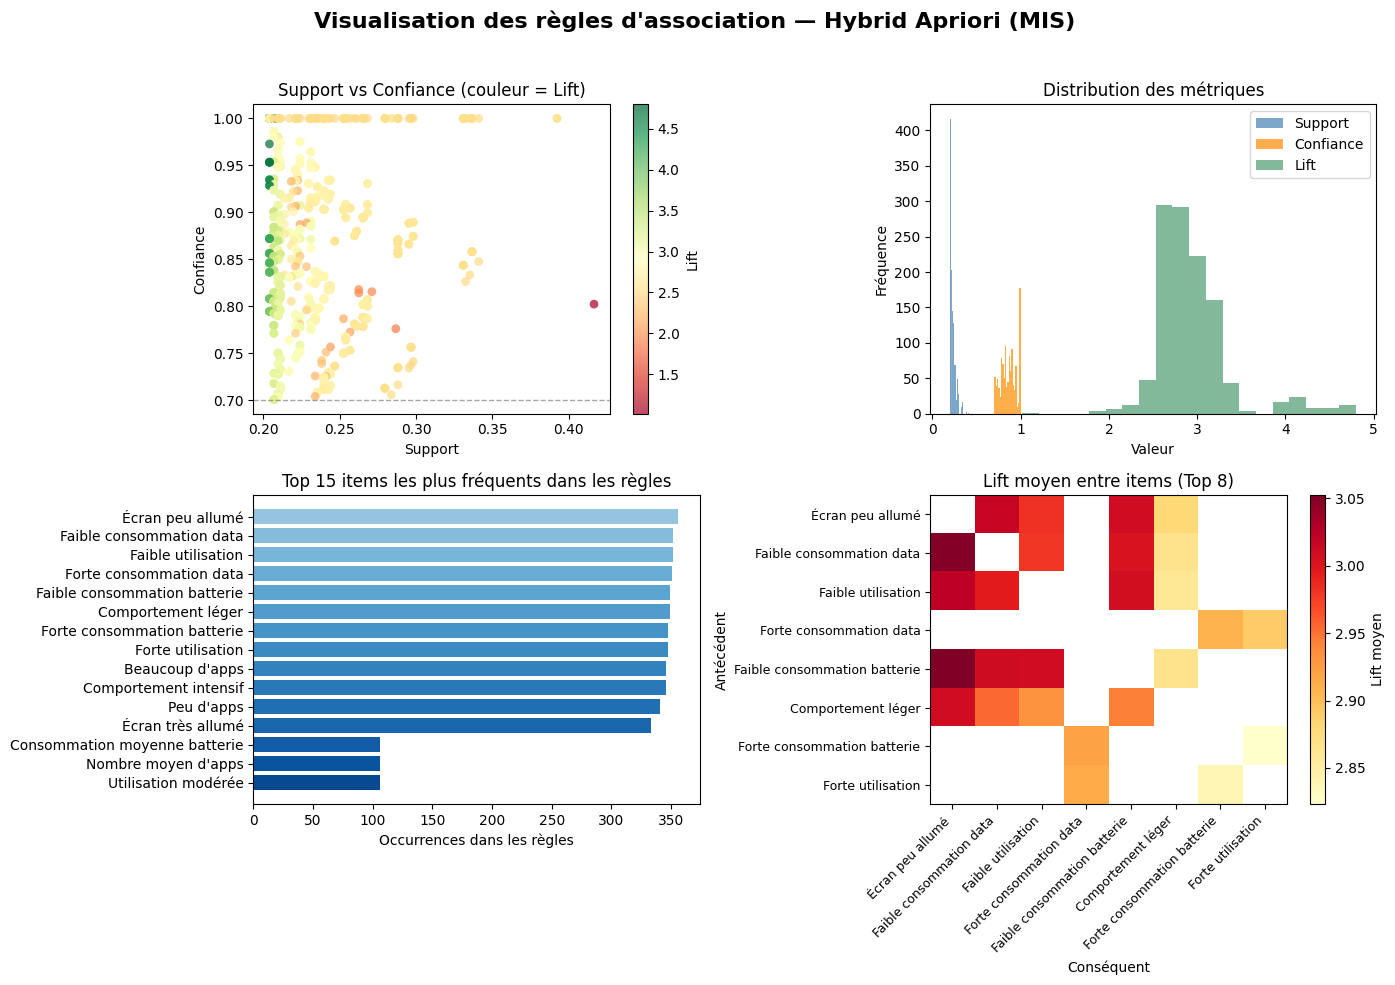

Visualisations sauvegardées dans : visualisations_hybrid_mis.png


In [ ]:
print("\nGenerating visualizations...")

# Extract metrics
supports_vals   = [r[2] for r in regles]
confiances_vals = [r[3] for r in regles]
lifts_vals      = [r[4] for r in regles]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Visualisation des règles d'association — Hybrid Apriori (MIS)", 
             fontsize=16, fontweight="bold")

# 1. Support vs Confidence (colored by Lift)
ax1 = axes[0, 0]
sc = ax1.scatter(supports_vals, confiances_vals, c=lifts_vals, 
                 cmap="RdYlGn", s=40, alpha=0.7, edgecolors="none")
plt.colorbar(sc, ax=ax1, label="Lift")
ax1.set_xlabel("Support")
ax1.set_ylabel("Confiance")
ax1.set_title("Support vs Confiance (couleur = Lift)")
ax1.axhline(y=0.7, color="grey", linestyle="--", linewidth=1, alpha=0.7)

# 2. Histograms
ax2 = axes[0, 1]
ax2.hist(supports_vals,   bins=20, alpha=0.7, label="Support",   color="steelblue")
ax2.hist(confiances_vals, bins=20, alpha=0.7, label="Confiance", color="darkorange")
ax2.hist(lifts_vals,      bins=20, alpha=0.6, label="Lift",      color="seagreen")
ax2.set_xlabel("Valeur")
ax2.set_ylabel("Fréquence")
ax2.set_title("Distribution des métriques")
ax2.legend()

# 3. Top 15 items
ax3 = axes[1, 0]
all_items = [item for ant, cons, *_ in regles for item in list(ant) + list(cons)]
item_counts = Counter(all_items).most_common(15)
items, freq = zip(*item_counts)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(items)))
ax3.barh(items[::-1], freq[::-1], color=colors[::-1])
ax3.set_xlabel("Occurrences dans les règles")
ax3.set_title("Top 15 items les plus fréquents dans les règles")
ax3.tick_params(axis='y', labelsize=10)

# 4. Lift Heatmap (Top 8 items)
ax4 = axes[1, 1]
top_items = [i for i, _ in Counter(all_items).most_common(8)]
matrix = np.zeros((len(top_items), len(top_items)))
counts = np.zeros((len(top_items), len(top_items)), dtype=int)

for ant, cons, sup, conf, lift in regles:
    for a in ant:
        for c in cons:
            if a in top_items and c in top_items:
                i = top_items.index(a)
                j = top_items.index(c)
                matrix[i][j] += lift
                counts[i][j] += 1

with np.errstate(invalid='ignore'):
    avg_lift = np.where(counts > 0, matrix / counts, np.nan)

im = ax4.imshow(avg_lift, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=ax4, label="Lift moyen")
ax4.set_xticks(range(len(top_items)))
ax4.set_yticks(range(len(top_items)))
ax4.set_xticklabels(top_items, rotation=45, ha="right", fontsize=9)
ax4.set_yticklabels(top_items, fontsize=9)
ax4.set_title("Lift moyen entre items (Top 8)")
ax4.set_xlabel("Conséquent")
ax4.set_ylabel("Antécédent")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("visualisations_hybrid_mis.png", dpi=160, bbox_inches="tight")
plt.show()

print("Visualisations sauvegardées dans : visualisations_hybrid_mis.png")